In [ ]:
import pandas as pd 


In [6]:
df = pd.read_csv("MobilesDataset(2025).csv", encoding='ISO-8859-1')
df

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year
0,Apple,iPhone 16 128GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 224,999","INR 79,999","CNY 5,799",USD 799,"AED 2,799",2024
1,Apple,iPhone 16 256GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 234,999","INR 84,999","CNY 6,099",USD 849,"AED 2,999",2024
2,Apple,iPhone 16 512GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 244,999","INR 89,999","CNY 6,499",USD 899,"AED 3,199",2024
3,Apple,iPhone 16 Plus 128GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 249,999","INR 89,999","CNY 6,199",USD 899,"AED 3,199",2024
4,Apple,iPhone 16 Plus 256GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 259,999","INR 94,999","CNY 6,499",USD 949,"AED 3,399",2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
925,Poco,Pad 5G 128GB,571g,8GB,8MP,8MP,Snapdragon 7s Gen 2,"10,000mAh",12.1 inches,"PKR 66,220","INR 23,999","CNY 2,099",USD 280,"AED 1,029",2024
926,Poco,Pad 5G 256GB,571g,8GB,8MP,8MP,Snapdragon 7s Gen 2,"10,000mAh",12.1 inches,"PKR 71,220","INR 25,999","CNY 2,299",USD 300,"AED 1,099",2024
927,Samsung,Galaxy Z Fold6 256GB,239g,12GB,"10MP, 4MP (UDC)",50MP,Snapdragon 8 Gen 3,4400mAh,7.6 inches,"PKR 604,999","INR 164,999","¥13,999","USD 1,899","AED 7,199",2024
928,Samsung,Galaxy Z Fold6 512GB,239g,12GB,"10MP, 4MP (UDC)",50MP,Snapdragon 8 Gen 3,4400mAh,7.6 inches,"PKR 544,999","INR 176,999","CNY 15,999",USD 1719,"AED 7,699",2024


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 930 entries, 0 to 929
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Company Name               930 non-null    object
 1   Model Name                 930 non-null    object
 2   Mobile Weight              930 non-null    object
 3   RAM                        930 non-null    object
 4   Front Camera               930 non-null    object
 5   Back Camera                930 non-null    object
 6   Processor                  930 non-null    object
 7   Battery Capacity           930 non-null    object
 8   Screen Size                930 non-null    object
 9   Launched Price (Pakistan)  930 non-null    object
 10  Launched Price (India)     930 non-null    object
 11  Launched Price (China)     930 non-null    object
 12  Launched Price (USA)       930 non-null    object
 13  Launched Price (Dubai)     930 non-null    object
 14  Launched Y

In [8]:
null_counts = df.isnull().sum()
print(null_counts)

Company Name                 0
Model Name                   0
Mobile Weight                0
RAM                          0
Front Camera                 0
Back Camera                  0
Processor                    0
Battery Capacity             0
Screen Size                  0
Launched Price (Pakistan)    0
Launched Price (India)       0
Launched Price (China)       0
Launched Price (USA)         0
Launched Price (Dubai)       0
Launched Year                0
dtype: int64


In [9]:
print(df.dtypes)


Company Name                 object
Model Name                   object
Mobile Weight                object
RAM                          object
Front Camera                 object
Back Camera                  object
Processor                    object
Battery Capacity             object
Screen Size                  object
Launched Price (Pakistan)    object
Launched Price (India)       object
Launched Price (China)       object
Launched Price (USA)         object
Launched Price (Dubai)       object
Launched Year                 int64
dtype: object


In [ ]:
df['RAM'] = df['RAM'].str.replace(r'[^\d.]', '', regex=True)  
df['RAM'] = df['RAM'].replace('', '0') 
df['RAM'] = df['RAM'].astype(float) 


In [ ]:
import re

def clean_number(text):
    if isinstance(text, str):
        cleaned = re.sub(r'[^\d.]', '', text)
        if cleaned.count('.') > 1:
            first_dot_index = cleaned.find('.')
            cleaned = cleaned[:first_dot_index + 1] + cleaned[first_dot_index + 1:].replace('.', '')
        return cleaned
    return text


In [15]:
columns_to_clean = [
    'Mobile Weight', 'RAM', 'Front Camera', 'Back Camera',
    'Battery Capacity', 'Screen Size',
    'Launched Price (Pakistan)', 'Launched Price (India)',
    'Launched Price (China)', 'Launched Price (USA)',
    'Launched Price (Dubai)'
]

for col in columns_to_clean:
    df[col] = df[col].astype(str)
    df[col] = df[col].apply(clean_number)
    df[col] = df[col].replace('', '0')  # optional: treat empty as 0
    df[col] = df[col].astype(float)


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 930 entries, 0 to 929
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Company Name               930 non-null    object 
 1   Model Name                 930 non-null    object 
 2   Mobile Weight              930 non-null    float64
 3   RAM                        930 non-null    float64
 4   Front Camera               930 non-null    float64
 5   Back Camera                930 non-null    float64
 6   Processor                  930 non-null    object 
 7   Battery Capacity           930 non-null    float64
 8   Screen Size                930 non-null    float64
 9   Launched Price (Pakistan)  930 non-null    float64
 10  Launched Price (India)     930 non-null    float64
 11  Launched Price (China)     930 non-null    float64
 12  Launched Price (USA)       930 non-null    float64
 13  Launched Price (Dubai)     930 non-null    float64

In [17]:
df

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year
0,Apple,iPhone 16 128GB,174.0,6.0,12.0,48.0,A17 Bionic,3600.0,6.1,224999.0,79999.0,5799.0,799.0,2799.0,2024
1,Apple,iPhone 16 256GB,174.0,6.0,12.0,48.0,A17 Bionic,3600.0,6.1,234999.0,84999.0,6099.0,849.0,2999.0,2024
2,Apple,iPhone 16 512GB,174.0,6.0,12.0,48.0,A17 Bionic,3600.0,6.1,244999.0,89999.0,6499.0,899.0,3199.0,2024
3,Apple,iPhone 16 Plus 128GB,203.0,6.0,12.0,48.0,A17 Bionic,4200.0,6.7,249999.0,89999.0,6199.0,899.0,3199.0,2024
4,Apple,iPhone 16 Plus 256GB,203.0,6.0,12.0,48.0,A17 Bionic,4200.0,6.7,259999.0,94999.0,6499.0,949.0,3399.0,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
925,Poco,Pad 5G 128GB,571.0,8.0,8.0,8.0,Snapdragon 7s Gen 2,10000.0,12.1,66220.0,23999.0,2099.0,280.0,1029.0,2024
926,Poco,Pad 5G 256GB,571.0,8.0,8.0,8.0,Snapdragon 7s Gen 2,10000.0,12.1,71220.0,25999.0,2299.0,300.0,1099.0,2024
927,Samsung,Galaxy Z Fold6 256GB,239.0,12.0,104.0,50.0,Snapdragon 8 Gen 3,4400.0,7.6,604999.0,164999.0,13999.0,1899.0,7199.0,2024
928,Samsung,Galaxy Z Fold6 512GB,239.0,12.0,104.0,50.0,Snapdragon 8 Gen 3,4400.0,7.6,544999.0,176999.0,15999.0,1719.0,7699.0,2024


In [32]:
df.to_csv("cleaned_mobile_data.csv", index=False)


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 930 entries, 0 to 929
Data columns (total 30 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Company Name                      930 non-null    object 
 1   Model Name                        930 non-null    object 
 2   Mobile Weight                     930 non-null    float64
 3   RAM                               930 non-null    float64
 4   Front Camera                      930 non-null    float64
 5   Back Camera                       930 non-null    float64
 6   Processor                         930 non-null    object 
 7   Battery Capacity                  930 non-null    float64
 8   Screen Size                       930 non-null    float64
 9   Launched Price (Pakistan)         930 non-null    float64
 10  Launched Price (India)            930 non-null    float64
 11  Launched Price (China)            930 non-null    float64
 12  Launched

In [37]:
print(df.columns.tolist())

['Company Name', 'Model Name', 'Mobile Weight', 'RAM', 'Front Camera', 'Back Camera', 'Processor', 'Battery Capacity', 'Screen Size', 'Launched Price (Pakistan)', 'Launched Price (India)', 'Launched Price (China)', 'Launched Price (USA)', 'Launched Price (Dubai)', 'Launched Year', 'Price_USD_INR', 'Price_CNY_INR', 'Price_AED_INR', 'Price_PKR_INR', 'Price_INR', 'Converted Price (USA) [INR]', 'Converted Price (China) [INR]', 'Converted Price (Dubai) [INR]', 'Converted Price (Pakistan) [INR]', 'Converted Price (India) [INR]', 'Price in INR (USA)', 'Price in INR (China)', 'Price in INR (Dubai)', 'Price in INR (Pakistan)', 'Price in INR (India)']


In [38]:
columns_to_delete = [
    'Price_USD_INR', 'Price_CNY_INR', 'Price_AED_INR', 'Price_PKR_INR', 'Price_INR',
    'Converted Price (USA) [INR]', 'Converted Price (China) [INR]',
    'Converted Price (Dubai) [INR]', 'Converted Price (Pakistan) [INR]',
    'Converted Price (India) [INR]', 'Price in INR (USA)', 'Price in INR (China)',
    'Price in INR (Dubai)', 'Price in INR (Pakistan)', 'Price in INR (India)'
]

# Drop columns (ignore errors if any columns are missing)
df.drop(columns=columns_to_delete, inplace=True, errors='ignore')

# Save changes permanently
df.to_csv("cleaned_mobile_data.csv", index=False)

# Confirm result
print("Deleted columns successfully. Updated columns:")
print(df.columns.tolist())

Deleted columns successfully. Updated columns:
['Company Name', 'Model Name', 'Mobile Weight', 'RAM', 'Front Camera', 'Back Camera', 'Processor', 'Battery Capacity', 'Screen Size', 'Launched Price (Pakistan)', 'Launched Price (India)', 'Launched Price (China)', 'Launched Price (USA)', 'Launched Price (Dubai)', 'Launched Year']


In [ ]:
exchange_rates = {
    'Launched Price (Pakistan)': ('Price in INR (Pakistan)', 0.30),
    'Launched Price (China)': ('Price in INR (China)', 11.43),
    'Launched Price (USA)': ('Price in INR (USA)', 83.0),
    'Launched Price (Dubai)': ('Price in INR (Dubai)', 22.6),
}
for original_col, (new_col, rate) in exchange_rates.items():
    df[new_col] = df[original_col] * rate

df.to_csv("cleaned_mobile_data.csv", index=False)

# Confirm column names
print("New INR columns added successfully.")
print(df.columns.tolist())

✅ New INR columns added successfully.
['Company Name', 'Model Name', 'Mobile Weight', 'RAM', 'Front Camera', 'Back Camera', 'Processor', 'Battery Capacity', 'Screen Size', 'Launched Price (Pakistan)', 'Launched Price (India)', 'Launched Price (China)', 'Launched Price (USA)', 'Launched Price (Dubai)', 'Launched Year', 'Price in INR (Pakistan)', 'Price in INR (China)', 'Price in INR (USA)', 'Price in INR (Dubai)']


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 930 entries, 0 to 929
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Company Name               930 non-null    object 
 1   Model Name                 930 non-null    object 
 2   Mobile Weight              930 non-null    float64
 3   RAM                        930 non-null    float64
 4   Front Camera               930 non-null    float64
 5   Back Camera                930 non-null    float64
 6   Processor                  930 non-null    object 
 7   Battery Capacity           930 non-null    float64
 8   Screen Size                930 non-null    float64
 9   Launched Price (Pakistan)  930 non-null    float64
 10  Launched Price (India)     930 non-null    float64
 11  Launched Price (China)     930 non-null    float64
 12  Launched Price (USA)       930 non-null    float64
 13  Launched Price (Dubai)     930 non-null    float64

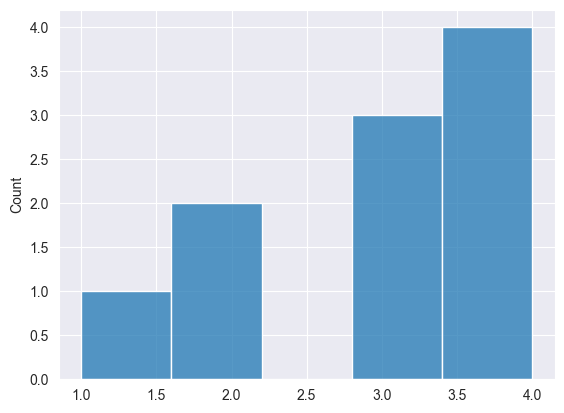

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("darkgrid")
sns.histplot([1,2,2,3,3,3,4,4,4,4])
plt.show()


SyntaxError: invalid syntax (107951413.py, line 1)